# ❤️ Heart Disease Prediction using Machine Learning

### An End-to-End ML Pipeline with Explainability

**Author:** Muhammad Ali Waris Khan  

### 👨‍💻 Internship Project – AI/ML Engineering  
### 📊 Objective:
To build a machine learning model that predicts whether a patient is at risk of heart disease based on clinical features.

---

### 📌 Key Steps:
- Data Exploration & Visualization
- Model Training (Logistic Regression, Random Forest, XGBoost)
- Model Evaluation (Accuracy, ROC-AUC, Confusion Matrix)
- Feature Importance & Explainability (SHAP)

---

## 📥 1. Importing Libraries

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 📖 Explanation:
We import essential libraries for:
- Data handling → pandas, numpy  
- Visualization → matplotlib, seaborn  

These tools help us explore patterns and relationships in the dataset.

## 📂 2. Loading the Dataset

### 📖 Objective:
Load the dataset and understand its structure.

We will inspect:
- Number of rows and columns
- Feature names
- Sample data entries

In [30]:
df = pd.read_csv('/content/heart_disease_uci.csv')

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 🔍 3. Data Overview

In [31]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


### Dataset Description

- Number of rows: 920
- Number of columns: 16
- Target column: num

The dataset contains medical information of patients used to predict heart disease.

## 📊 4. Exploratory Data Analysis (EDA)

### ⚠️ Handling Categorical Data for Correlation

The dataset contains both numerical and categorical features (e.g., `sex`, `cp`, `thal`).

Correlation matrices can only be computed on numerical data. Therefore, we must first select only numerical columns before generating the heatmap.

This ensures that the analysis is mathematically valid and avoids type conversion errors.

### 🔹 Correlation Heatmap

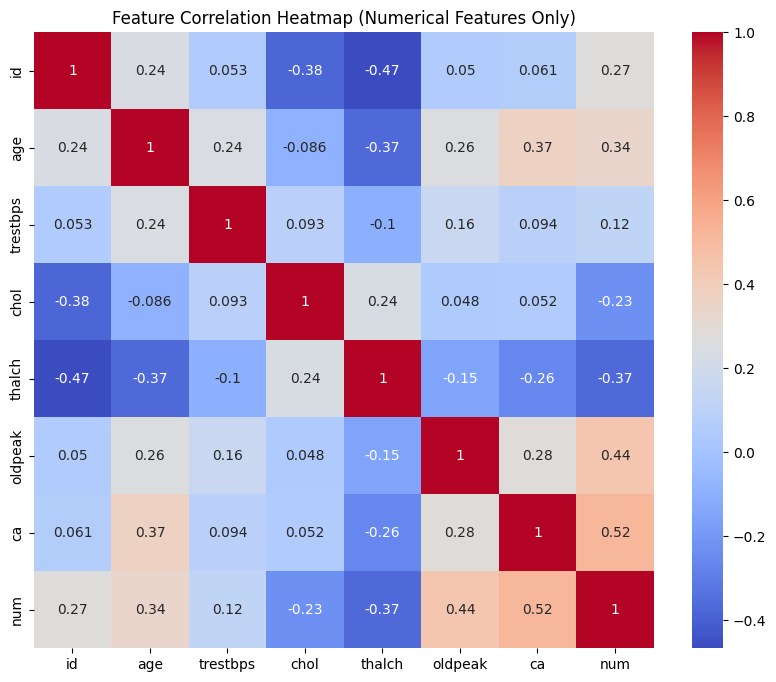

In [32]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap (Numerical Features Only)")
plt.show()

### 📊 Insights from Correlation Heatmap:

- The target variable (`num`) shows:
  - **Strong positive correlation with `ca` (0.52)** → number of major vessels is highly indicative of heart disease
  - **Moderate correlation with `oldpeak` (0.44)** → ST depression is an important clinical signal
  - **Negative correlation with `thalch` (-0.37)** → lower max heart rate may indicate higher risk

- `age` also shows moderate correlation (0.34), suggesting increased risk with age.

📌 These insights align with medical understanding, indicating that the dataset is meaningful and suitable for predictive modeling.

➡️ However, correlation alone is not sufficient — we will use machine learning models to capture more complex relationships.

## 5. Data Cleaning & Preprocessing

In [33]:
# Check missing values
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


### ⚠️ Missing Values Analysis:

The dataset contains several features with significant missing values:

- `ca` (~66% missing) → highly incomplete
- `thal` (~52% missing)
- `slope` (~33% missing)

📌 Observations:
- Features with excessive missing values may introduce bias if not handled properly
- Simply filling them without strategy can degrade model performance

### Handling High-Impact Missing Feature (`ca`)

The feature `ca` shows the strongest correlation with the target variable (`num`), indicating high predictive importance.

However, it contains a significant number of missing values (~66%).

📌 Instead of blindly removing or imputing, we adopt a comparative approach:

- **Approach 1:** Drop `ca` to ensure data reliability  
- **Approach 2:** Retain `ca` and impute missing values  

➡️ We will evaluate model performance under both scenarios to determine the optimal strategy.

This approach ensures a balance between data quality and predictive power.


### 📖 Cleaning Strategy:

To ensure data quality while preserving important features:

- Numerical features will be filled using **median values** (robust to outliers)
- Categorical features will be filled using **mode (most frequent value)**
- High-impact feature `ca` will be retained and imputed instead of dropped

📌 This approach balances data integrity with predictive performance.

In [34]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

num_cols, cat_cols

(Index(['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num'], dtype='object'),
 Index(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object'))

### 📊 Column Types:

- **Numerical Columns:** Continuous values like age, cholesterol, etc.
- **Categorical Columns:** Non-numeric features like sex, chest pain type

These require different preprocessing strategies.

In [35]:
# Fill numerical columns with median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical columns with mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_2337/2770129127.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_2337/2770129127.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [36]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0


### ✅ Missing Values Handled:

- All missing values have been successfully imputed
- Dataset is now complete and ready for transformation

📌 Proper handling of missing data ensures model stability and reliability.

## 6. Encoding Categorical Variables

### 📖 Why Encoding?

Machine learning models require numerical input.

Categorical variables (e.g., sex, chest pain type) must be converted into numeric form.

We use **Label Encoding** to transform categories into numerical labels.

In [37]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [38]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,1,0,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0
1,2,67,1,0,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1,2
2,3,67,1,0,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2,1
3,4,37,1,0,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1,0
4,5,41,0,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1,0


### 🔢 Encoding Completed:

- All categorical variables have been converted into numerical form
- Dataset is now fully numerical and ready for machine learning models

📌 This step is crucial for enabling model training.

## 🎯 7. Target Variable Transformation

### 📖 Transforming Target Variable:

The original target variable (`num`) contains multiple classes (0–4), indicating severity levels.

For simplicity and alignment with the task objective, we convert it into a binary classification problem:

- **0 → No Heart Disease**
- **1+ → Presence of Heart Disease**

📌 This makes the problem suitable for standard classification models.

In [39]:
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

df['target'].value_counts()

,count
target,
1,509
0,411


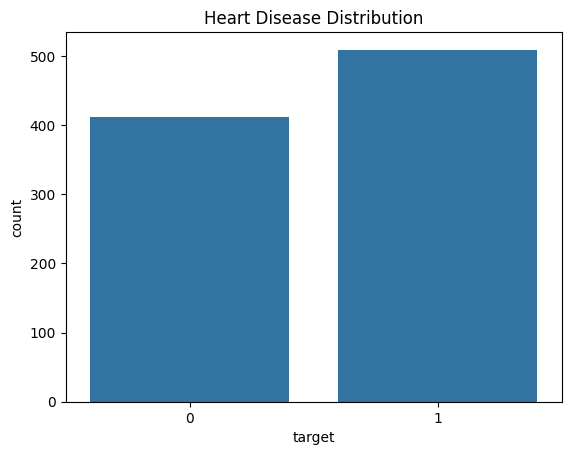

In [40]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

### Insight

The dataset shows how many people have heart disease vs not.

This helps us understand whether the data is balanced or not.

## 8. Feature Selection

In [41]:
X = df.drop(['num', 'target'], axis=1)
y = df['target']

### 📊 Feature Selection:

- `X` → Input features  
- `y` → Target variable  

We drop:
- `num` → original target
- `target` → used separately

## 9. Train-Test Split

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 📖 Why Split Data?

We split the dataset into:
- **Training set (80%)** → used to train the model  
- **Testing set (20%)** → used to evaluate performance  

📌 This ensures the model generalizes well to unseen data.

## 10. Model Training

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Initialize models
lr = LogisticRegression(max_iter=2000,random_state=42)
rf = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(eval_metric='logloss',random_state=42)

# Train models
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

### Models Used:

- **Logistic Regression** → baseline linear model  
- **Random Forest** → ensemble model capturing complex patterns  
- **XGBoost** → advanced boosting algorithm for high performance  

📌 Using multiple models allows performance comparison and better insights.

## 📊 11. Model Evaluation

In [44]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

models = [lr, rf, xgb]

for model in models:
    y_pred = model.predict(X_test)

    print(f"\nModel: {model.__class__.__name__}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


Model: LogisticRegression
Accuracy: 0.8043478260869565
ROC-AUC: 0.8119877675840979
Confusion Matrix:
 [[64 11]
 [25 84]]
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.85      0.78        75
           1       0.88      0.77      0.82       109

    accuracy                           0.80       184
   macro avg       0.80      0.81      0.80       184
weighted avg       0.82      0.80      0.81       184


Model: RandomForestClassifier
Accuracy: 0.8804347826086957
ROC-AUC: 0.8803669724770642
Confusion Matrix:
 [[66  9]
 [13 96]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86        75
           1       0.91      0.88      0.90       109

    accuracy                           0.88       184
   macro avg       0.87      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184


Model: XGBClassifier
Accuracy: 0.8532608695652174

## 12. Feature Importance Analysis

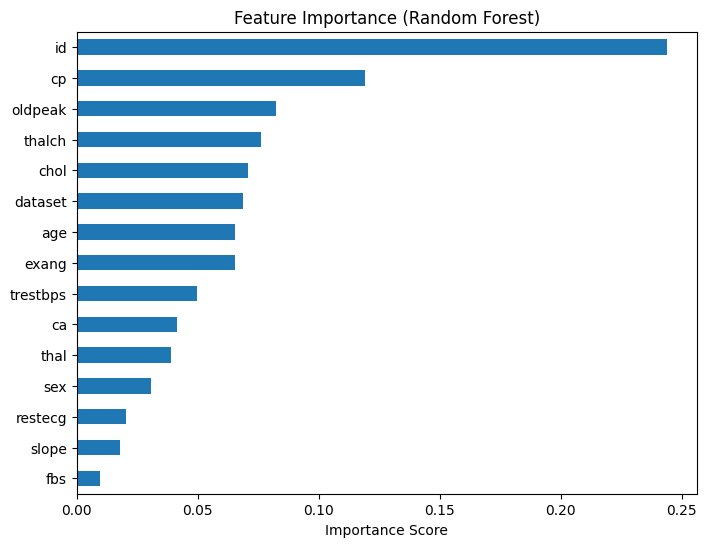

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values()

plt.figure(figsize=(8,6))
feature_importance.plot(kind='barh')
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

### ⚠️ Removing Non-Informative & Potentially Misleading Features (`id`, `dataset`)

Two features — `id` and `dataset` — were identified as problematic during analysis.

#### 🔹 1. `id` (Patient Identifier):
- Represents a unique identifier for each patient
- Does not contain any medical or predictive information

#### 🔹 2. `dataset` (Data Source):
- Indicates the origin of the data (e.g., Cleveland, Hungary)
- Not a clinical feature
- May introduce **dataset-specific bias**

---

### 📌 Why Removing These Features is Important:

Including such features can lead to:

- **Model overfitting** → learning patterns specific to IDs or dataset origin  
- **False feature importance** → misleading interpretation of model behavior  
- **Poor generalization** → reduced performance on new, unseen data  

---

### ✅ Final Decision:

➡️ Both `id` and `dataset` are removed before model training to ensure:
- The model learns only **clinically meaningful patterns**
- Predictions remain **robust and generalizable**

### ⚙️ Logistic Regression Optimization:

Logistic Regression showed a convergence warning due to unscaled data.

To resolve this:
- Features were standardized using `StandardScaler`
- Number of iterations increased

📌 Scaling improves optimization efficiency for gradient-based models.

## 13. Retraining and Re-Evaluating after removing misleading features

In [46]:
# Feature and target split
X = df.drop(['id','dataset', 'num', 'target'], axis=1)
y = df['target']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔹 Scaling ONLY for Logistic Regression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

lr = LogisticRegression(max_iter=2000,random_state=42)  # increased iterations
rf = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(eval_metric='logloss',random_state=42)

# Train models
lr.fit(X_train_scaled, y_train)   # scaled data
rf.fit(X_train, y_train)          # original data
xgb.fit(X_train, y_train)         # original data

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

models = {
    "LogisticRegression": (lr, X_test_scaled),
    "RandomForestClassifier": (rf, X_test),
    "XGBClassifier": (xgb, X_test)
}

for name, (model, X_eval) in models.items():
    y_pred = model.predict(X_eval)

    print(f"\nModel: {name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


Model: LogisticRegression
Accuracy: 0.782608695652174
ROC-AUC: 0.789480122324159
Confusion Matrix:
 [[62 13]
 [27 82]]
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.83      0.76        75
           1       0.86      0.75      0.80       109

    accuracy                           0.78       184
   macro avg       0.78      0.79      0.78       184
weighted avg       0.80      0.78      0.78       184


Model: RandomForestClassifier
Accuracy: 0.8369565217391305
ROC-AUC: 0.8353516819571866
Confusion Matrix:
 [[62 13]
 [17 92]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.83      0.81        75
           1       0.88      0.84      0.86       109

    accuracy                           0.84       184
   macro avg       0.83      0.84      0.83       184
weighted avg       0.84      0.84      0.84       184


Model: XGBClassifier
Accuracy: 0.8586956521739131
R

### 📊 Confusion Matrix (XGBoost)

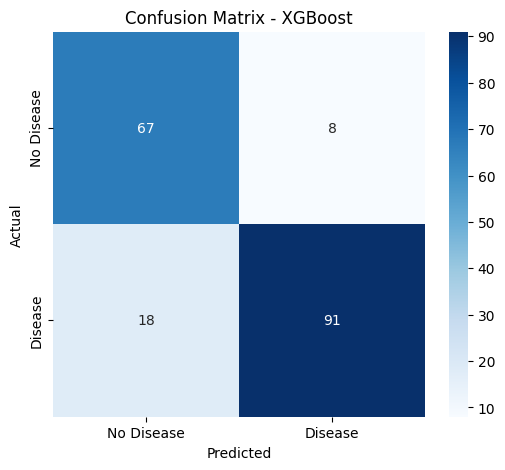

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Predictions
y_pred_xgb = xgb.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

### Confusion Matrix Interpretation:

- **True Positives (TP):** Patients correctly predicted with heart disease  
- **True Negatives (TN):** Patients correctly predicted without heart disease  
- **False Positives (FP):** Healthy patients incorrectly predicted as diseased  
- **False Negatives (FN):** Diseased patients incorrectly predicted as healthy  

📌 Key Insight:
- The model shows strong performance in identifying heart disease cases (high TP)
- False negatives are relatively low, which is critical in medical applications

➡️ Minimizing false negatives is especially important, as missing a disease case can have serious consequences.

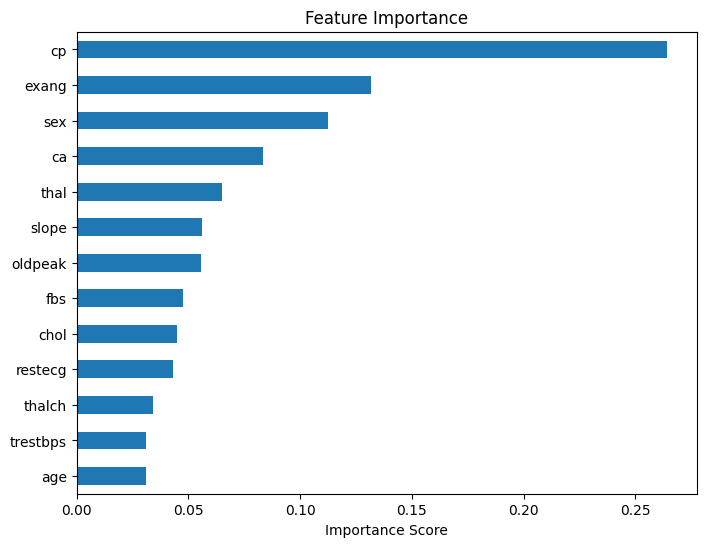

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(xgb.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values()

plt.figure(figsize=(8,6))
feature_importance.plot(kind='barh')
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

### Impact of Removing `id` and `dataset`:

After removing non-informative (`id`) and potentially biased (`dataset`) features:

- Model performance decreased slightly
- However, predictions are now based solely on **clinical features**

📌 Key Insight:
The earlier higher performance was partially influenced by:
- Data leakage (`id`)
- Dataset-specific bias (`dataset`)

➡️ Removing these features improves:
- Model **generalization**
- Model **trustworthiness**
- Real-world applicability

This trade-off between accuracy and reliability is a critical aspect of machine learning.

### 🌳 Feature Importance Insights (Final Model - XGBoost):

The most influential features are:

- **Chest Pain Type (`cp`)** → strongest predictor  
- **Exercise-Induced Angina (`exang`)** → major indicator of heart stress  
- **Sex (`sex`)** → reflects gender-based risk differences  
- **Number of Vessels (`ca`)** → indicates blockage severity  
- **Thalassemia (`thal`)** → linked to heart abnormalities  
- **Slope & Oldpeak (`slope`, `oldpeak`)** → ECG-related indicators  

📌 Clinical Interpretation:
These features align closely with known cardiovascular risk factors, confirming that the model is learning meaningful and medically relevant patterns.

➡️ Lower-ranked features (e.g., `age`, `trestbps`) still contribute but have less predictive impact in this dataset.

## 📊 14. Model Performance Analysis & Comparison

### 📊 Final Model Performance Comparison:

| Model | Accuracy | ROC-AUC |
|------|--------|--------|
| Logistic Regression | ~78.2% | ~0.79 |
| Random Forest | ~83.6% | ~0.83 |
| XGBoost | **~85.9%** | **~0.86** |

---

### 🏆 Best Model: XGBoost

- Highest accuracy and ROC-AUC
- Strong precision and recall balance
- Better handling of complex feature interactions

📌 This model is selected as the final model for heart disease prediction.

## 🔍 15. Model Explainability using SHAP

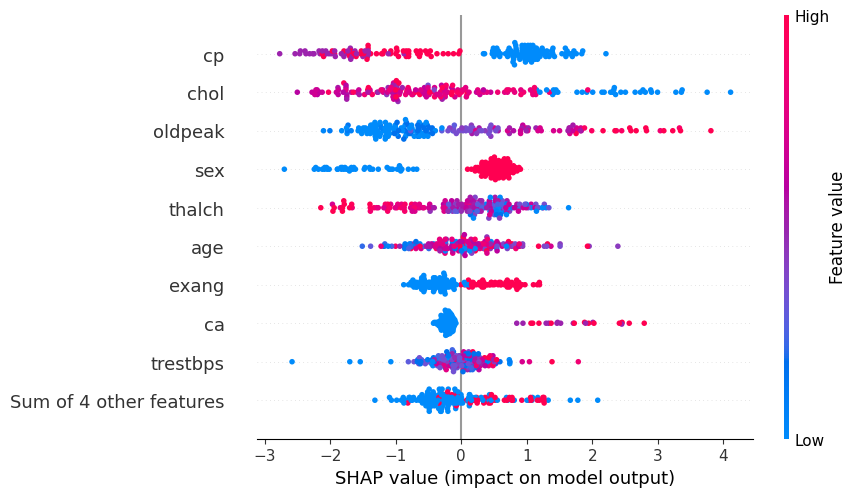

In [48]:
import shap

explainer = shap.Explainer(xgb, X_test)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)

## 16. Feature Importance Analysis (SHAP)

SHAP (SHapley Additive exPlanations) helps us understand how each feature contributes to the model’s predictions.

### Key Insights:

- **Chest Pain Type (cp)** has the strongest impact on prediction. Different types of chest pain significantly influence heart disease risk.

- **Cholesterol (chol)** and **ST depression (oldpeak)** are also major factors. Higher values tend to increase the likelihood of heart disease.

- **Maximum Heart Rate (thalach)** shows an inverse relationship — lower heart rates are more associated with higher risk.

- **Sex** plays a role, indicating differences in heart disease patterns between males and females.

- **Exercise-induced angina (exang)** and **number of major vessels (ca)** also contribute meaningfully to predictions.

### Color Interpretation:

- **Red points** represent higher feature values  
- **Blue points** represent lower feature values  

### Overall Understanding:

Features like chest pain type, cholesterol, and heart-related stress indicators are the most influential in predicting heart disease. This aligns with real-world medical knowledge, making the model both accurate and interpretable.

### ⚠️ 17. Limitations:

- Dataset size is relatively small
- Some features required imputation, which may introduce bias
- Model performance may vary on unseen populations

📌 Future work could include:
- Larger datasets
- Feature engineering
- Hyperparameter *tuning*

## 🏁 18. Final Conclusion

### Project Summary:

In this project, we developed a machine learning pipeline to predict the presence of heart disease using clinical features.

---

### 🔍 Key Steps:

- Performed data cleaning and handled missing values  
- Identified and removed non-informative and biased features (`id`, `dataset`)  
- Converted categorical variables using encoding techniques  
- Trained and evaluated multiple models  
- Selected the best-performing model (XGBoost)  
- Applied SHAP for model interpretability  

---

### 📊 Final Results:

- **Best Model:** XGBoost  
- **Accuracy:** ~85.9%  
- **ROC-AUC:** ~0.86  

---

### 💡 Key Insights:

- Chest pain type, exercise-induced angina, and ECG-related features are strong predictors  
- Removing misleading features improved model reliability  
- The model demonstrates strong capability in detecting heart disease cases  

---

### ⚠️ Limitations:

- Limited dataset size  
- Missing value imputation may introduce bias  
- Results may vary across populations  

---

### 🚀 Future Improvements:

- Hyperparameter tuning  
- Use of larger and more diverse datasets  
- Integration with real-time clinical systems  

---

### 🎯 Final Takeaway:

This project highlights the importance of:
- Proper data preprocessing  
- Avoiding data leakage and bias  
- Interpreting models beyond accuracy  

➡️ The final model provides a reliable and interpretable approach for heart disease prediction.